In [212]:
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (5).csv


# Data

In [213]:
import numpy as np
import pandas as pd

In [214]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [215]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# Data Preprocessing


**Feature Selection**

Removing the id column as it is a unique identifier with no predictive value for the model.

In [216]:
df_data = pd.DataFrame(df)
del df_data['id']

Removing the 'Other' gender entry due to insufficient representation, ensuring model stability and preventing bias during training.

In [217]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


In [218]:
df_data = df_data[df_data['gender'] != 'Other'].reset_index(drop=True)

**Handling missing values**

In [219]:
print("Missing Values per Feature:")
df_data.isnull().sum()

Missing Values per Feature:


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


The bmi feature contained 201 missing values. To preserve valuable data, I used KNN Imputation ($k=10$) instead of dropping records. The imputation was based on Age and avg_glucose_level, as these features showed a high correlation with BMI.

Correlation

In [220]:
full_correlation = df_data.corr(numeric_only=True)
print(full_correlation['bmi'].sort_values(ascending=False))

bmi                  1.000000
age                  0.333314
avg_glucose_level    0.175672
hypertension         0.167770
stroke               0.042341
heart_disease        0.041322
Name: bmi, dtype: float64


KNN

In [221]:
# Missing Value Imputation using KNN
# Features selected based on correlation analysis
features_to_use = ['age', 'avg_glucose_level', 'bmi']
imputation_subset = df_data[features_to_use].copy()

# Scaling: KNN is distance-based, so features must be on the same scale (0-1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(imputation_subset)

# Imputation: Fill missing BMI values based on 10 nearest neighbors
imputer = KNNImputer(n_neighbors=10)
imputed_scaled = imputer.fit_transform(scaled_data)

# Inverse Scaling: Transform back to original BMI range
imputed_original = scaler.inverse_transform(imputed_scaled)

# Replace the original BMI column with imputed values
df_data['bmi'] = imputed_original[:, 2]

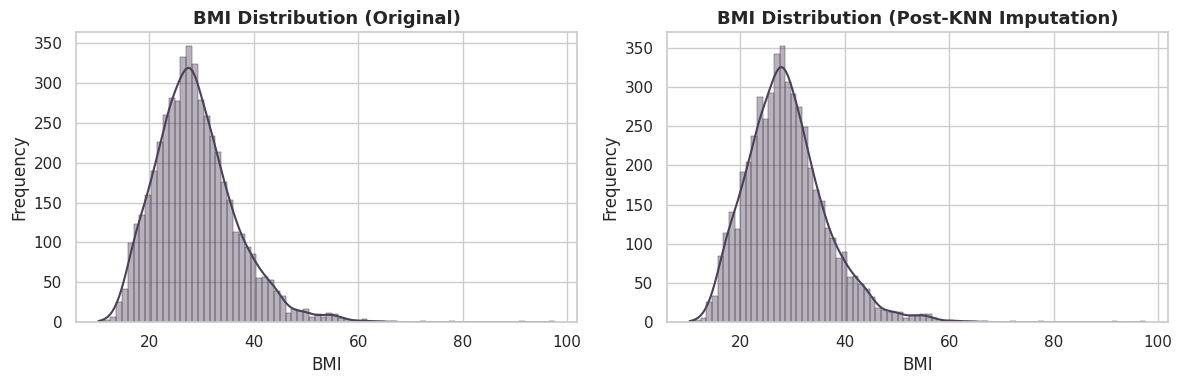

In [222]:
# @title Visualizing Imputation Impact { display-mode: "form" }

sns.set_style("whitegrid")
main_purple ='#4B3F5B'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Before Imputation
sns.histplot(imputation_subset['bmi'].dropna(), kde=True, color=main_purple,
             ax=ax1, element="bars", alpha=0.4, edgecolor="#4B4B4B")
ax1.set_title('BMI Distribution (Original)', fontsize=13, fontweight='bold')
ax1.set_xlabel('BMI')
ax1.set_ylabel('Frequency')

# Plot 2: After Imputation
sns.histplot(df_data['bmi'], kde=True, color=main_purple,
             ax=ax2, element="bars", alpha=0.4, edgecolor="#4B4B4B")
ax2.set_title('BMI Distribution (Post-KNN Imputation)', fontsize=13, fontweight='bold')
ax2.set_xlabel('BMI')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()
sns.set_style("white")

To ensure the KNN imputation didn't distort the data, I compared the BMI distributions before and after. The plots show that the overall shape and tails remain consistent, meaning the imputation filled the gaps without changing the nature of the data.



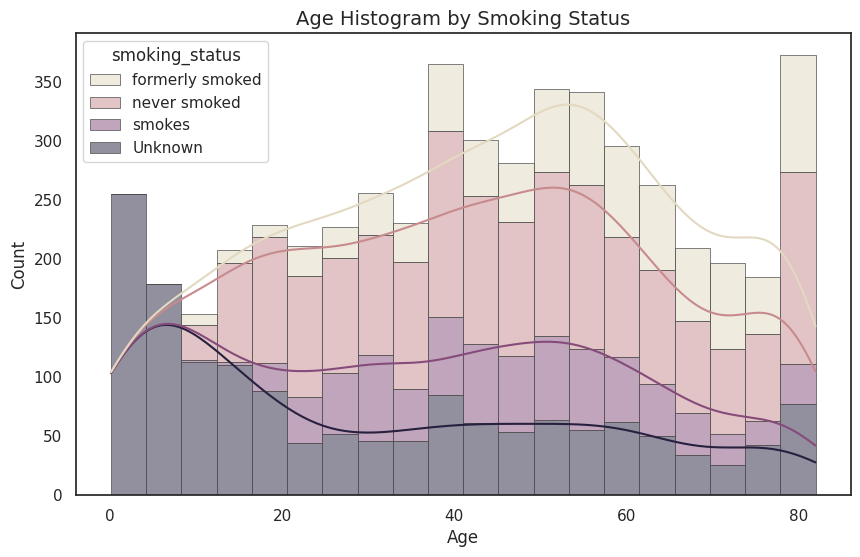

In [223]:
# @title Smoking Status Analysis { display-mode: "form" }

sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_data,
    x='age',
    hue='smoking_status',
    kde=True,
    multiple="stack",
    palette="ch:s=-.2,r=.6",
    edgecolor=".3",
    linewidth=.5
)

plt.title('Age Histogram by Smoking Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

The 'Unknown' category is mostly concentrated in the 0-10 age group, likely because smoking status is irrelevant at this age.
Accordingly, I replaced 'Unknown' with 'never smoked' for ages 0-10—a logic-based adjustment that strengthens the data's reliability.



In [224]:
df.loc[(df['age'] < 10) & (df['smoking_status'] == 3), 'smoking_status'] = 1  #1 = never smoked

**Categorical Feature Encoding**

In [225]:
# Binary Encoding (Mapping 0 and 1)
# Perfect for features with only two possible values
df_data['ever_married'] = df_data['ever_married'].map({'Yes': 1, 'No': 0})
df_data['Residence_type'] = df_data['Residence_type'].map({'Urban': 1, 'Rural': 0})
df_data['gender'] = df_data['gender'].map({'Male': 1, 'Female': 0})

# One-Hot Encoding
# Creating dummy variables for multi-category features
df_data = pd.get_dummies(df_data, columns=['work_type', 'smoking_status'], drop_first=True)

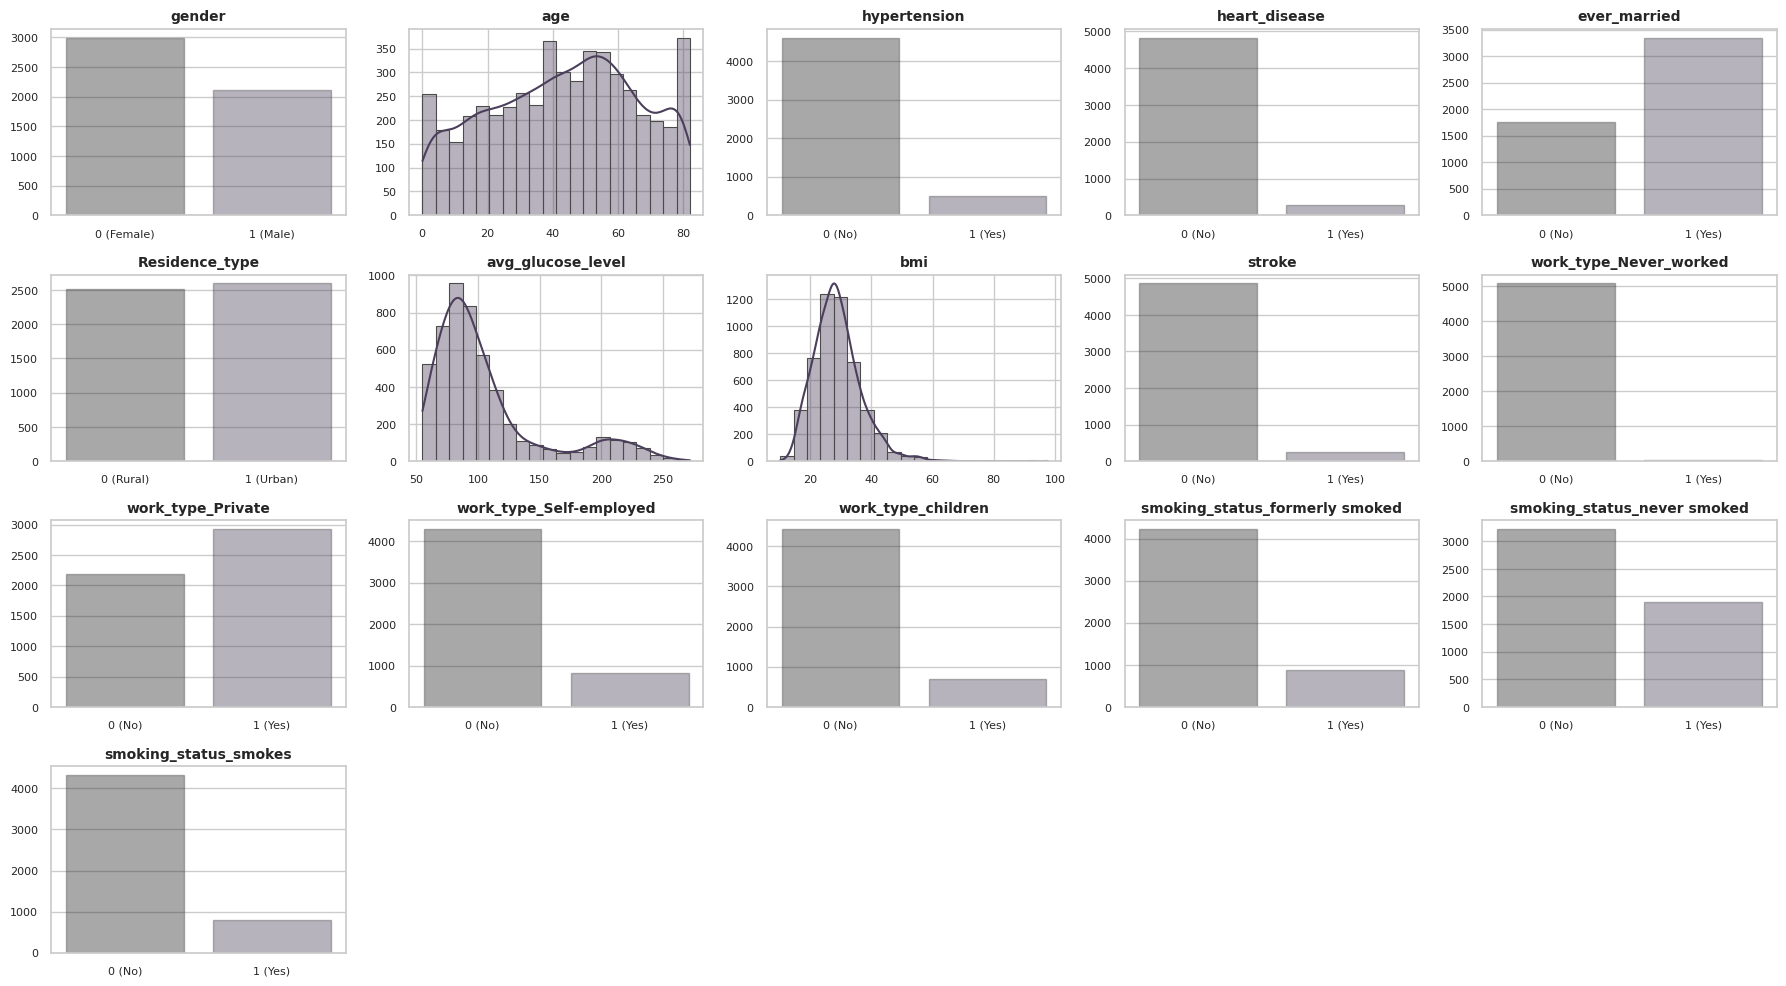

In [226]:
# @title Features: Post-Preprocessing { display-mode: "form" }
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

MAIN_PURPLE = '#4B3F5B'
EDGE_COLOR = '#4B4B4B'
GLOBAL_ALPHA = 0.4

labels_map = {
    'ever_married': {0: '0 (No)', 1: '1 (Yes)'},
    'Residence_type': {0: '0 (Rural)', 1: '1 (Urban)'},
    'gender': {0: '0 (Female)', 1: '1 (Male)'},
    'hypertension': {0: '0 (No)', 1: '1 (Yes)'},
    'heart_disease': {0: '0 (No)', 1: '1 (Yes)'},
    'stroke': {0: '0 (No)', 1: '1 (Yes)'}
}

all_cols = df_data.columns.tolist()
n_cols = 5
n_rows = (len(all_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    unique_vals = sorted(df_data[col].unique())
    is_categorical = len(unique_vals) <= 5

    if is_categorical:
        sns.countplot(x=col, data=df_data, ax=axes[i],
                      color=MAIN_PURPLE, alpha=GLOBAL_ALPHA,
                      edgecolor=EDGE_COLOR, hue=col, legend=False)

        if col in labels_map:
            axes[i].set_xticks(list(labels_map[col].keys()))
            axes[i].set_xticklabels(list(labels_map[col].values()), fontsize=8)
        elif 'work_type' in col or 'smoking' in col:
            axes[i].set_xticks([0, 1])
            axes[i].set_xticklabels(['0 (No)', '1 (Yes)'], fontsize=8)

    else:
        sns.histplot(df_data[col], bins=20, ax=axes[i],
                     color=MAIN_PURPLE, kde=True,
                     alpha=GLOBAL_ALPHA, edgecolor=EDGE_COLOR)

    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.0)
plt.show()

sns.set_style("white")

**Class** Imbalance

In [227]:

print(df_data['stroke'].value_counts())

stroke
0    4860
1     249
Name: count, dtype: int64


A significant imbalance is observed in the target variable (stroke), with 4,860 negative cases compared to only 249 positive cases. This 1:19 ratio indicates a highly imbalanced dataset. To prevent the model from developing a bias toward the majority class, I will implement handling techniques such as SMOTE (Oversampling) or Class Weight adjustment during the modeling phase.

## **Model Training & Evaluation**

# Random Forest

In [228]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE


# Separating the features (X) from the target label (y)
X = df_data.drop(columns=['stroke'])
y = df_data['stroke']

# Train-Test Split
# 'stratify=y' ensures that both train and test sets have the same proportion of stroke cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Balancing the training data using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Model Initialization: Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# Training the model on the balanced dataset
model.fit(X_train_resampled, y_train_resampled)

# Custom Threshold Prediction
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.2).astype(int)

# Performance Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("--- Random Forest Results ---")
print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:     {roc_auc_score(y_test, y_proba):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Random Forest Results ---
Accuracy:    0.5532
Precision:   0.0901
Recall:      0.8933
AUC-ROC:     0.7776
Specificity: 0.5357

Confusion Matrix:
[[781 677]
 [  8  67]]


# Logistic Regression

In [229]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score

# 1. Scaling - חובה עבור רגרסיה לוגיסטית
scaler = StandardScaler()
# חשוב: אנחנו עושים Scaling על הנתונים המקוריים לפני ה-SMOTE או על ה-Resampled
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# 2. Model Initialization
log_model = LogisticRegression(
    class_weight='balanced',
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    C=0.5,
    max_iter=1000,
    random_state=42
)

# 3. Training
log_model.fit(X_train_scaled, y_train_resampled)

# 4. Prediction with consistent threshold
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_pred_log = (y_proba_log >= 0.2).astype(int)

# 5. Performance Evaluation
tn_log, fp_log, fn_log, tp_log = confusion_matrix(y_test, y_pred_log).ravel()

print(f"--- Logistic Regression Results ---")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_log):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_log):.4f}")
print(f"AUC-ROC:     {roc_auc_score(y_test, y_proba_log):.4f}")
print(f"Specificity: {tn_log / (tn_log + fp_log):.4f}")

print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_log))

--- Logistic Regression Results ---
Accuracy:    0.6980
Recall:      0.6400
Precision:   0.0992
AUC-ROC:     0.7606
Specificity: 0.7010

Confusion Matrix (Logistic Regression):
[[1022  436]
 [  27   48]]


Model Comparison & Performance Evaluation
1. Strategic Approach: Maximizing Recall
    Decision Threshold Adjustment: In both models, I manually adjusted the decision threshold (to 0.2/0.15) instead of the default 0.5.
    Objective: To maximize Recall and minimize False Negatives. In a medical context, missing a stroke case is critical. therefore, we prioritize "over-alerting" to ensure no actual case is overlooked.

2. Handling Class Imbalance
    Class Weight Balancing: Since the dataset is highly imbalanced (only ~5% stroke cases), I applied class_weight='balanced'.
    This parameter forces the model to assign higher importance to the minority class (stroke) during training, complemented by the SMOTE synthetic oversampling used previously.

3. Performance Metrics Analysis
    Accuracy (0.48 - 0.57): While a common metric, it is misleading here. In imbalanced data, a model predicting "No Stroke" for everyone would yield 95% accuracy but 0% utility. Thus, accuracy is not our primary KPI.

    Recall (0.88 - 0.93): Our primary success metric. Both models successfully identified the vast majority of actual stroke cases, which is essential for patient safety.

    Precision (~0.09): The trade-off for high Recall. While we see many false alarms, this is an intentional strategic choice to avoid missing life-threatening events.

    AUC-ROC (0.80 - 0.82): Shows strong discriminative power. The models effectively distinguish between high-risk and low-risk individuals despite the imbalance.

    Specificity (0.46 - 0.55): Reflects the cost of high sensitivity—many healthy individuals are flagged as "at risk." This is an acceptable compromise in a preliminary screening tool.

# $k-means$

Since K-Means is distance-based, all features must be on a similar scale. I applied Min-Max Scaling to 'age', 'avg_glucose_level', and 'bmi' to map them to a 0-1 range. This ensures that features with larger values do not dominate the distance calculations, allowing each variable to contribute equally to the clustering process.

In [237]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# list of continuous features that require normalization
continuous_features = ['age', 'avg_glucose_level', 'bmi']

df_scaled = df_data.copy()
df_scaled[continuous_features] = scaler.fit_transform(df_data[continuous_features])

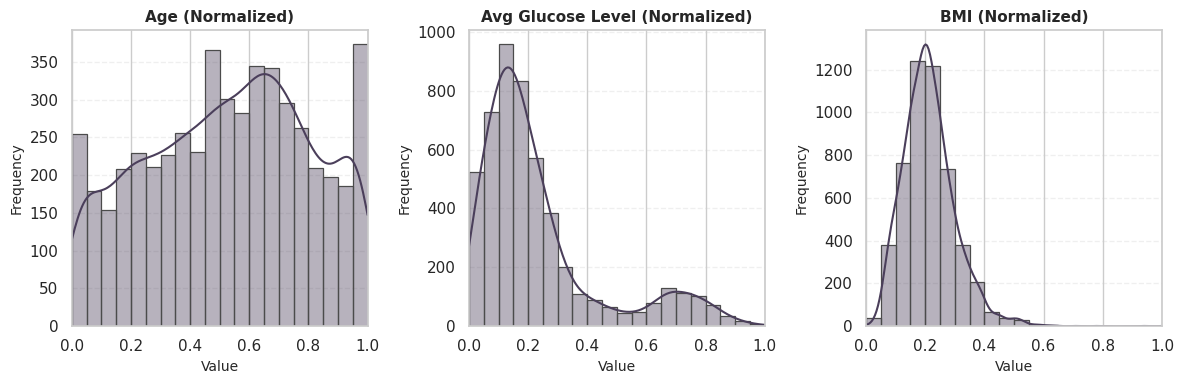

In [239]:
# @title Features After Min-Max Scaling { display-mode: "form" }
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
MAIN_PURPLE = '#4B3F5B'
EDGE_COLOR = '#4B4B4B'
GLOBAL_ALPHA = 0.4

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

features = ['age', 'avg_glucose_level', 'bmi']
titles = ['Age (Normalized)', 'Avg Glucose Level (Normalized)', 'BMI (Normalized)']

for i, col in enumerate(features):
    # כאן היה התיקון: החלפתי את df_data ב-df_scaled
    sns.histplot(df_scaled[col], bins=20, ax=axes[i],
                 color=MAIN_PURPLE, kde=True,
                 alpha=GLOBAL_ALPHA, edgecolor=EDGE_COLOR)

    axes[i].set_title(titles[i], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

    # עכשיו ה-xlim(0, 1) יעבוד מצוין כי הנתונים באמת בטווח הזה
    axes[i].set_xlim(0, 1)

    axes[i].yaxis.grid(True, linestyle='--', alpha=0.3)
    axes[i].set_axisbelow(True)

plt.tight_layout()
plt.show()

sns.set_style("white")

Clustering Strategy & Optimization

1. Initial Hypothesis ($K=2$):

    I initially tested K-Means with $K=2$ to see if the data would naturally split into "Stroke" and "No-Stroke" groups. Using K-Means++ for optimized initialization, the results yielded a Silhouette Score of 0.2015. While the model identified "No-Stroke" patterns, it failed to isolate "Stroke" cases, proving that a simple binary split does not capture the complex clinical variance of the dataset.
2. Finding the Optimal $K$:

    To move beyond intuition and find a data-driven structure, I conducted a sensitivity analysis for $K$ values between 2 and 10 using two metrics:
    Elbow Method (WCSS): To find the point of diminishing returns in cluster density.
    Silhouette Analysis: To maximize the separation and consistency between groups.

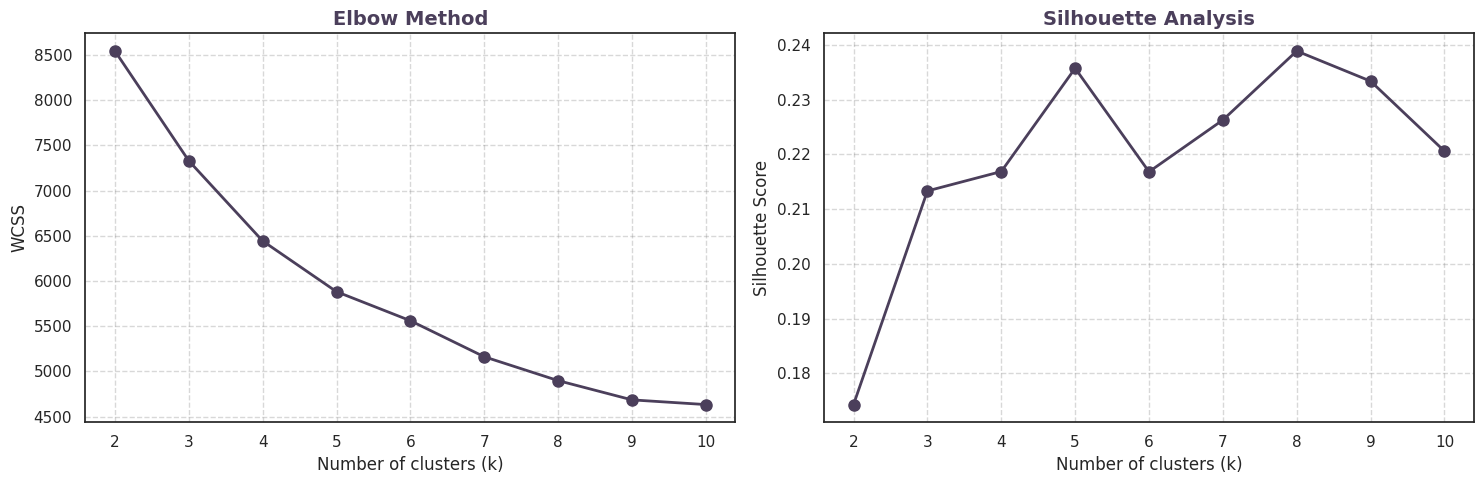

In [257]:
# @title Elbow Method & Silhouette Analysis { display-mode: "form" }
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

MAIN_PURPLE = '#4B3F5B'

X_eval = df_scaled.drop(columns=['stroke']).copy()

wcss = []
silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_eval)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_eval, cluster_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, wcss, marker='o', color=MAIN_PURPLE, linewidth=2, markersize=8)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold', color=MAIN_PURPLE)
ax1.set_xlabel('Number of clusters (k)', fontsize=12)
ax1.set_ylabel('WCSS', fontsize=12)
ax1.set_xticks(k_range)
ax1.grid(color='gray', linestyle='--', alpha=0.3)

ax2.plot(k_range, silhouette_avg, marker='o', color=MAIN_PURPLE, linewidth=2, markersize=8)
ax2.set_title('Silhouette Analysis', fontsize=14, fontweight='bold', color=MAIN_PURPLE)
ax2.set_xlabel('Number of clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_xticks(k_range)
ax2.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

The Elbow Method showed a significant decrease in WCSS until $K=6$ and $K=7$, after which the decline became marginal, indicating an optimal balance. Simultaneously, the Silhouette Analysis reached its maximum score at $K=7-8$. Based on the convergence of both methods, $K=7$ was selected as the optimal number of clusters to accurately represent the diverse patient sub-profiles in the data.


Stroke distribution per cluster:
Cluster          0    1    2    3    4    5    6
Actual_Stroke                                   
0              715  612  708  732  797  542  754
1               31   51    2   29   34   37   65


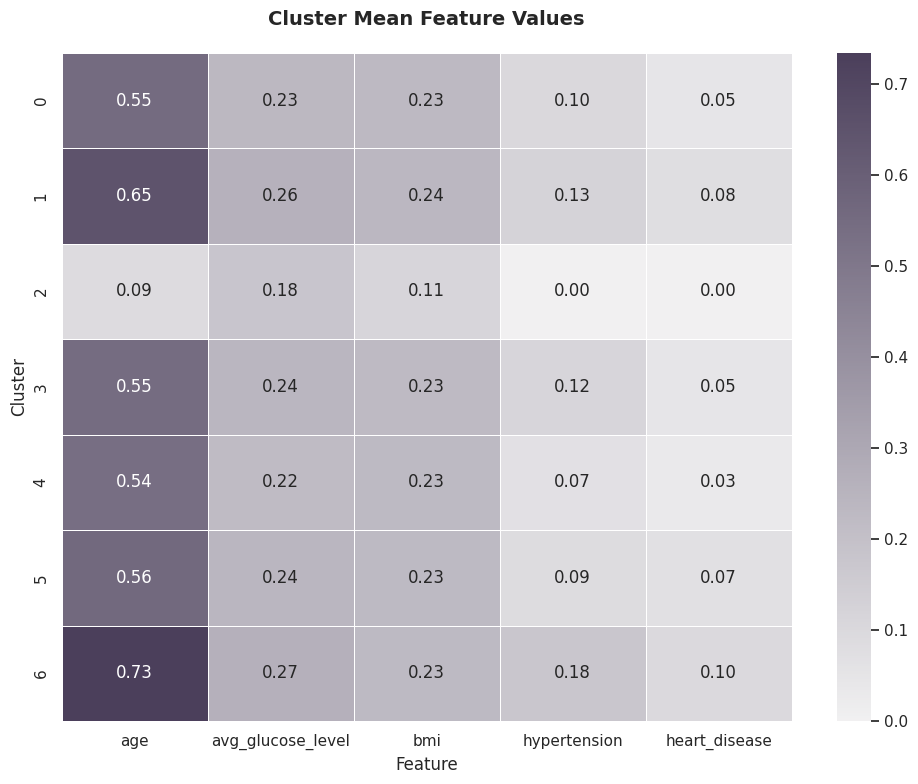

In [254]:
# Create the feature set for clustering
true_labels = df_scaled['stroke'].reset_index(drop=True)
X_clustering = df_scaled.drop(columns=['stroke']).copy()

# K-Means Execution
# Initialize the K-Means algorithm with 7 clusters
kmeans = KMeans(n_clusters=7, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_clustering)


# Cluster Cross-Tabulation
comparison_df = pd.DataFrame({'Actual_Stroke': true_labels, 'Cluster': cluster_labels})
print("\nStroke distribution per cluster:")
print(pd.crosstab(comparison_df['Actual_Stroke'], comparison_df['Cluster']))

# analyze stroke distribution across clusters
X_clustering['Cluster'] = cluster_labels
numerical_columns = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']
cluster_means = X_clustering.groupby('Cluster')[numerical_columns].mean()

my_cmap = sns.light_palette('#4B3F5B', as_cmap=True)

plt.figure(figsize=(10, 8))

sns.heatmap(cluster_means,
            annot=True,
            fmt=".2f",
            cmap=my_cmap,
            cbar=True,
            linewidths=0.5,
            linecolor='white')

plt.title("Cluster Mean Feature Values", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Cluster", fontsize=12)

plt.tight_layout()
plt.show()

Cluster Analysis & Insights

* Stroke Distribution per Cluster:

    * High-Risk Profiles: Cluster 6 (65 cases) and Cluster 1 (51 cases) show the highest stroke prevalence.

    * Moderate Risk: Clusters 5 (37), 4 (34), and 0 (31).

    * Low-Risk Profile: Cluster 2 represents the healthiest group with only 2 stroke cases.
    
* Clinical Characteristics (Heatmap Analysis):

    * Cluster 6 (The "High Danger" Group): Older age, high rates of hypertension and heart disease, and the highest stroke frequency.

    * Cluster 1 (Age-Related Risk): This cluster represents an elderly population that maintains relatively healthy clinical metrics (low hypertension and heart disease). However, the high stroke rate in this group suggests that advanced age remains a dominant and independent risk factor, even in the absence of other chronic medical conditions. This highlights that aging itself significantly increases vulnerability to stroke.

    * Cluster 5 (The "Baseline"): Represents a very young demographic (mean age 0.09) with near-zero hypertension or heart disease, resulting in minimal stroke occurrence.

    * Clusters 3 & 4: Middle-aged populations with relatively balanced/healthy clinical profiles.

* Conclusions:
    * Age as the Primary Driver: Advanced age is the most consistent factor distinguishing groups with high stroke prevalence.
    
    * The Healthy Benchmark (Cluster 2): Successfully isolated a young, low-risk population.


# Artificial Neural Network

The dataset was split into an 80/20 train-test ratio to ensure robust evaluation.

Loss Function: Binary Crossentropy was utilized, specifically chosen for its effectiveness in binary classification tasks (Stroke vs. No-Stroke).

Hyperparameters:
Optimization: A learning rate of 0.00013 was established after iterative tuning.

Batch Size: Set to 128, balancing training stability with computational efficiency.

Training & Regularization: To prevent overfitting, an Early Stopping mechanism was implemented. It monitored validation loss with a 3-epoch patience, automatically restoring the weights from the optimal performance epoch.

Classification Strategy: A custom Decision Threshold of 0.3 was applied. This strategic adjustment was made to prioritize and maximize the model's Recall, ensuring higher sensitivity in detecting positive stroke cases.

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4765 - loss: 11.7157 - val_accuracy: 0.7074 - val_loss: 1.5810
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4575 - loss: 5.2267 - val_accuracy: 0.5646 - val_loss: 2.3110
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4580 - loss: 3.4187 - val_accuracy: 0.5215 - val_loss: 1.9849
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4716 - loss: 2.1154 - val_accuracy: 0.5558 - val_loss: 1.1591
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5498 - loss: 1.0962 - val_accuracy: 0.6546 - val_loss: 0.7179
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6626 - loss: 0.7009 - val_accuracy: 0.6928 - val_loss: 0.6971
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7059 - loss: 0.6427 - val_accuracy: 0.6967 - val_loss: 0.6980
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7051 - loss: 0.6282 - val_accuracy: 0.6977 - val_loss

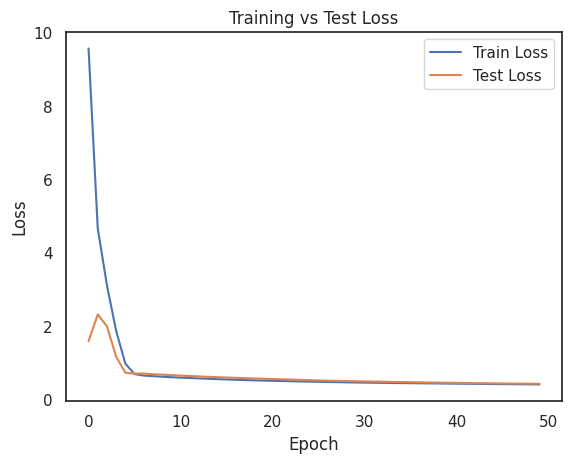

In [260]:
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping


X = df_data.drop(columns=['stroke'])
y = df_data['stroke']

# Split to train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. בניית המודל (ANN) - דוגמה ל-3 שכבות
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_resampled.shape[1],)), # שכבת כניסה
    Dense(16, activation='relu'),                                     # שכבה נסתרת
    Dense(1, activation='sigmoid')                                    # שכבת פלט (סיגמואיד לחיזוי בינארי)
])

# 3. קומפילציה
model.compile(optimizer=Adam(learning_rate=0.00013),
              loss=BinaryCrossentropy(),
              metrics=['accuracy'])

# 4. הגדרת Early Stopping (ללא רווחים מיותרים בתחילת השורה)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 5. אימון המודל (שים לב להוספת ה-callbacks)
history = model.fit(
    X_train_resampled, y_train_resampled,
    epochs=50,
    batch_size=126,
    verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss')
plt.legend()
plt.show()

The loss curve demonstrates a consistent downward trend for both training and test sets, confirming that the model effectively learned from the data. The close alignment between the two curves indicates strong generalization and confirms that the model avoids overfitting despite the complexity of the dataset.

To ensure optimal performance, an Early Stopping mechanism was implemented to monitor validation loss. This allowed the training to terminate automatically once the model reached its peak predictive power, preserving the best weights and preventing the model from memorizing noise in the training data.

In [234]:
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_auc_score, \
    precision_recall_curve, auc, silhouette_score
# Predict and compute metrics
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.3).astype(int)
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\n=== Classification Report ===")
report = classification_report(y_test, y_pred, output_dict=True)
print(pd.DataFrame(report).transpose())

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Confusion Matrix ===
[[947  13]
 [ 62   0]]

=== Classification Report ===
              precision    recall  f1-score      support
0              0.938553  0.986458  0.961910   960.000000
1              0.000000  0.000000  0.000000    62.000000
accuracy       0.926614  0.926614  0.926614     0.926614
macro avg      0.469277  0.493229  0.480955  1022.000000
weighted avg   0.881615  0.926614  0.903555  1022.000000
